In [53]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel, wilcoxon
from scipy.spatial.distance import euclidean
from scipy.stats import spearmanr
from math import pi
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

## English Dataset

In [2]:
# 1. Define dimensions
# Motor dimensions (5)
motor_dims = ['Foot', 'Hand', 'Head', 'Mouth', 'Torso']
# Sensory dimensions (6)
sensory_dims = ['Auditory', 'Gustatory', 'Haptic', 'Interoceptive', 'Olfactory', 'Visual']
# All dimensions
all_dims = motor_dims + sensory_dims

# 2. Define model list 
models = {
    'Human': '.mean',   
    'Base': '_base',
    'En_FT': '_en_ft',
    'Nl_FT': '_nl_ft',
    'QA_FT': '_qa_ft'
}
model_names = ['Base', 'En_FT', 'Nl_FT', 'QA_FT']

# 3. Load data
file_path = "En_all_models_results.xlsx"  
try:
    df = pd.read_excel(file_path)
    df.columns = df.columns.str.lower()
    print("Data loaded successfully, rows:", len(df))
except FileNotFoundError:
    print(f"Error: File {file_path} not found. Please update path.")

Data loaded successfully, rows: 1572


### calculate similarity

In [3]:
def calculate_euclidean_based_sim(row, suffix_model, suffix_human, dimensions):
    try:
        # 1. Get column names
        cols_model = [f'{dim.lower()}{suffix_model}' for dim in dimensions]
        cols_human = [f'{dim.lower()}{suffix_human}' for dim in dimensions]
        
        # 2. Extract data and convert to float
        # Use pd.to_numeric for conversion, invalid becomes NaN
        vec_model = row[cols_model].apply(pd.to_numeric, errors='coerce').values.astype(float)
        vec_human = row[cols_human].apply(pd.to_numeric, errors='coerce').values.astype(float)

        # 3. Check for NaN or Inf
        # If any vector contains NaN or Inf, distance cannot be calculated, return np.nan (filtered out later)
        if np.isnan(vec_model).any() or np.isinf(vec_model).any() or \
           np.isnan(vec_human).any() or np.isinf(vec_human).any():
            return np.nan

        # 4. Calculate Euclidean distance d
        d = euclidean(vec_model, vec_human)
        
        # 5. Convert to similarity
        return 1 / (1 + d)
        
    except Exception as e:
        # Return NaN for other errors (e.g., missing columns)
        return np.nan

In [42]:
# Calculate similarity list
results_sim = {}

analysis_types = {
    'All': all_dims,
    'Motor': motor_dims,
    'Sensory': sensory_dims
}

print("\nCalculating Euclidean similarity (1/(1+d))...")
for type_name, dims in analysis_types.items():
    print(f"--- Processing {type_name} Dimensions ---")
    results_sim[type_name] = pd.DataFrame({'word': df['word']}) 


    for model_name in model_names:
        model_suffix = models[model_name]
        human_suffix = models['Human']

        # Calculate Similarity for each row (word)
        sim_scores = df.apply(lambda row: calculate_euclidean_based_sim(row, model_suffix, human_suffix, dims), axis=1)
        results_sim[type_name][model_name] = sim_scores
        print(f"{model_name} vs Human (Mean Sim): {sim_scores.mean():.4f}")
        
# Save to Excel
with pd.ExcelWriter("en_word_wise_similarity_results.xlsx") as writer:
    for type_name, df_res in results_sim.items():
        df_res.to_excel(writer, sheet_name=type_name, index=False)
print("\nResults saved to 'en_word_wise_similarity_results.xlsx'")



Calculating Euclidean similarity (1/(1+d))...
--- Processing All Dimensions ---
Base vs Human (Mean Sim): 0.1551
En_FT vs Human (Mean Sim): 0.4123
Nl_FT vs Human (Mean Sim): 0.2378
QA_FT vs Human (Mean Sim): 0.1615
--- Processing Motor Dimensions ---
Base vs Human (Mean Sim): 0.2100
En_FT vs Human (Mean Sim): 0.5217
Nl_FT vs Human (Mean Sim): 0.2699
QA_FT vs Human (Mean Sim): 0.2295
--- Processing Sensory Dimensions ---
Base vs Human (Mean Sim): 0.2150
En_FT vs Human (Mean Sim): 0.5094
Nl_FT vs Human (Mean Sim): 0.4103
QA_FT vs Human (Mean Sim): 0.2189

Results saved to 'en_word_wise_similarity_results.xlsx'


In [5]:
def print_distribution_statistics(results_dict, model_list):
    """
    Print descriptive statistics for each dimension type in results_sim
    """
    print("\n" + "="*60)
    print("STATISTICAL DISTRIBUTION SUMMARY (Descriptive Statistics)")
    print("="*60)

    for dim_type, df_sim in results_dict.items():
        print(f"\n>>> Dimension Type: {dim_type}")
        print("-" * 60)
        
        # Extract data for relevant model columns
        # describe() automatically calculates count, mean, std, min, 25%, 50%, 75%, max
        stats_df = df_sim[model_list].describe().T  
        
        # Format output: 4 decimal places
        pd.set_option('display.float_format', lambda x: '%.4f' % x)
        print(stats_df[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])
        print("-" * 60)
        
        # Calculate IQR (Interquartile Range)
        iqr = stats_df['75%'] - stats_df['25%']
        print("Interquartile Range (IQR):")
        print(iqr)

print_distribution_statistics(results_sim, model_names)


STATISTICAL DISTRIBUTION SUMMARY (Descriptive Statistics)

>>> Dimension Type: All
------------------------------------------------------------
        mean    std    min    25%    50%    75%    max
Base  0.1551 0.0460 0.0761 0.1189 0.1486 0.1846 0.3635
En_FT 0.4123 0.0773 0.1873 0.3559 0.4093 0.4600 0.7373
Nl_FT 0.2378 0.0459 0.1289 0.2055 0.2319 0.2659 0.4833
QA_FT 0.1615 0.0455 0.0742 0.1279 0.1526 0.1879 0.4488
------------------------------------------------------------
Interquartile Range (IQR):
Base    0.0657
En_FT   0.1041
Nl_FT   0.0604
QA_FT   0.0600
dtype: float64

>>> Dimension Type: Motor
------------------------------------------------------------
        mean    std    min    25%    50%    75%    max
Base  0.2100 0.0776 0.0941 0.1538 0.1924 0.2502 0.7021
En_FT 0.5217 0.1086 0.2387 0.4421 0.5175 0.5984 0.8233
Nl_FT 0.2699 0.0596 0.1351 0.2281 0.2615 0.3025 0.5247
QA_FT 0.2295 0.0735 0.0974 0.1755 0.2148 0.2728 0.7341
------------------------------------------------------

#### Pairwise T-Test

In [40]:
# Pairwise T-test

def perform_statistical_tests(df_sim, type_name, models_compare=model_names):
    print(f"\n=== Statistical Test Results ({type_name}) ===")
    print(f"{'Comparison':<20} | {'T-stat':<10} | {'P-value':<10} | {'Sig'}")
    print("-" * 55)
    
    # Generate all pairwise combinations C(4, 2)
    pairs = list(itertools.combinations(models_compare, 2))
    
    for m1, m2 in pairs:
        temp_df = df_sim[[m1, m2]].dropna()
        
        scores1 = temp_df[m1]
        scores2 = temp_df[m2]
        
        # Pairwise T-test
        t_stat, p_val = ttest_rel(scores1, scores2)
        
        # Mark significance
        sig = ""
        if p_val < 0.001: sig = "***"
        elif p_val < 0.01: sig = "**"
        elif p_val < 0.05: sig = "*"
        else: sig = "ns"
        
        print(f"{m1} vs {m2:<10} | {t_stat: .4f}    | {p_val:.2e}   | {sig}")

# Execute tests
for type_name in analysis_types.keys():
    perform_statistical_tests(results_sim[type_name], type_name, model_names)


=== Statistical Test Results (All) ===
Comparison           | T-stat     | P-value    | Sig
-------------------------------------------------------
Base vs En_FT      | -110.7046    | 0.00e+00   | ***
Base vs Nl_FT      | -47.3904    | 5.20e-305   | ***
Base vs QA_FT      | -5.9526    | 3.25e-09   | ***
En_FT vs Nl_FT      |  91.7525    | 0.00e+00   | ***
En_FT vs QA_FT      |  117.0280    | 0.00e+00   | ***
Nl_FT vs QA_FT      |  47.4176    | 2.27e-305   | ***

=== Statistical Test Results (Motor) ===
Comparison           | T-stat     | P-value    | Sig
-------------------------------------------------------
Base vs En_FT      | -87.8035    | 0.00e+00   | ***
Base vs Nl_FT      | -22.1123    | 1.55e-94   | ***
Base vs QA_FT      | -9.1164    | 2.31e-19   | ***
En_FT vs Nl_FT      |  89.9357    | 0.00e+00   | ***
En_FT vs QA_FT      |  94.1944    | 0.00e+00   | ***
Nl_FT vs QA_FT      |  17.7980    | 1.07e-64   | ***

=== Statistical Test Results (Sensory) ===
Comparison           | T

### Visulaization

#### Boxplots

/var/folders/tb/rtz1nxvn4k5_jn2c158qm_wm0000gn/T/ipykernel_34683/3954554064.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='EuclideanSimilarity', data=plot_data, palette="Set3")


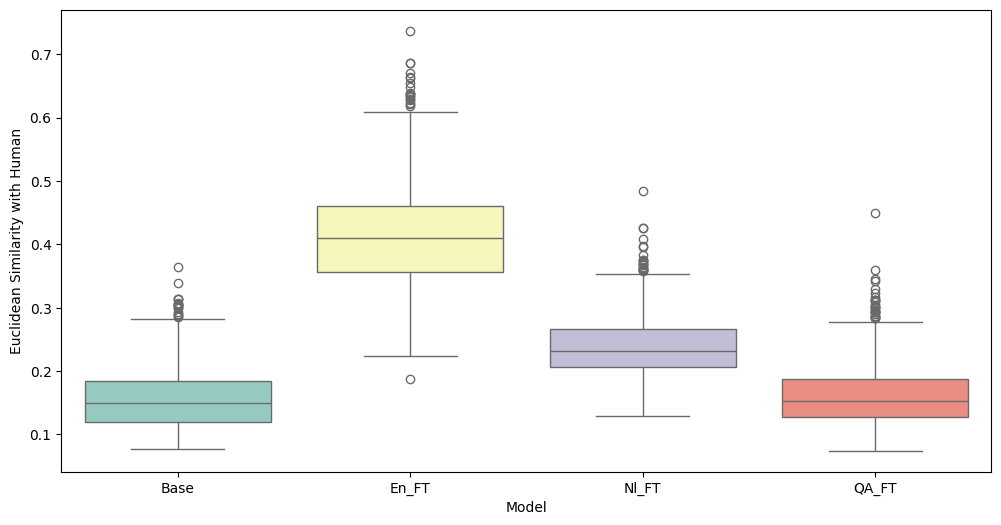

In [10]:
# ==========================================
# Visualize the distribution with Boxplots
# ==========================================

plt.figure(figsize=(12, 6))
plot_data = results_sim['All'].melt(id_vars=['word'], value_vars=model_names, var_name='Model', value_name='EuclideanSimilarity')
sns.boxplot(x='Model', y='EuclideanSimilarity', data=plot_data, palette="Set3")
#plt.title('Distribution of Word-wise Euclidean Similarity (All Dimensions)')
plt.ylabel('Euclidean Similarity with Human')
plt.show()

/var/folders/tb/rtz1nxvn4k5_jn2c158qm_wm0000gn/T/ipykernel_34683/3408137723.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='CosineSimilarity', data=plot_data, palette="Set3")


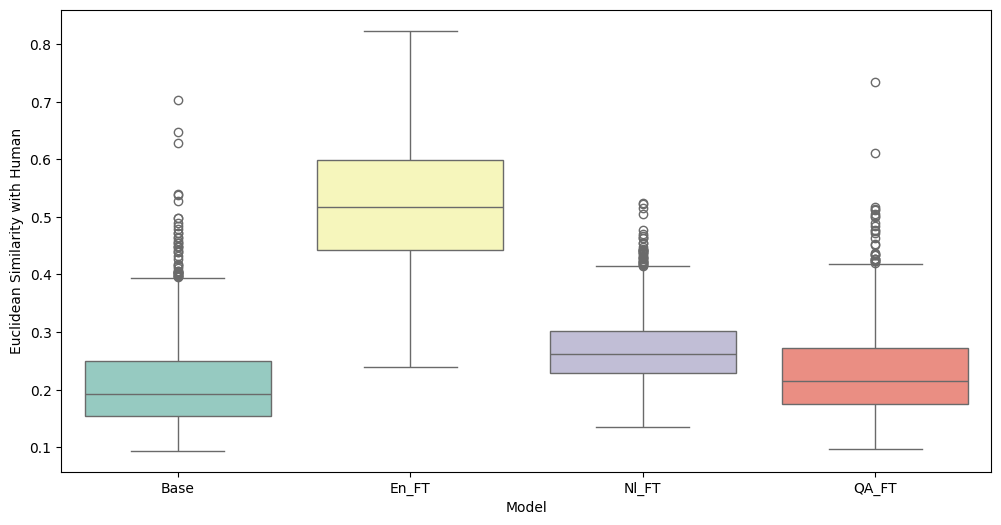

In [11]:
plt.figure(figsize=(12, 6))
plot_data = results_sim['Motor'].melt(id_vars=['word'], value_vars=model_names, var_name='Model', value_name='CosineSimilarity')
sns.boxplot(x='Model', y='CosineSimilarity', data=plot_data, palette="Set3")
#plt.title('Distribution of Word-wise Euclidean Similarity (Motor Dimensions)')
plt.ylabel('Euclidean Similarity with Human')
plt.show()

/var/folders/tb/rtz1nxvn4k5_jn2c158qm_wm0000gn/T/ipykernel_34683/511033477.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='CosineSimilarity', data=plot_data, palette="Set3")


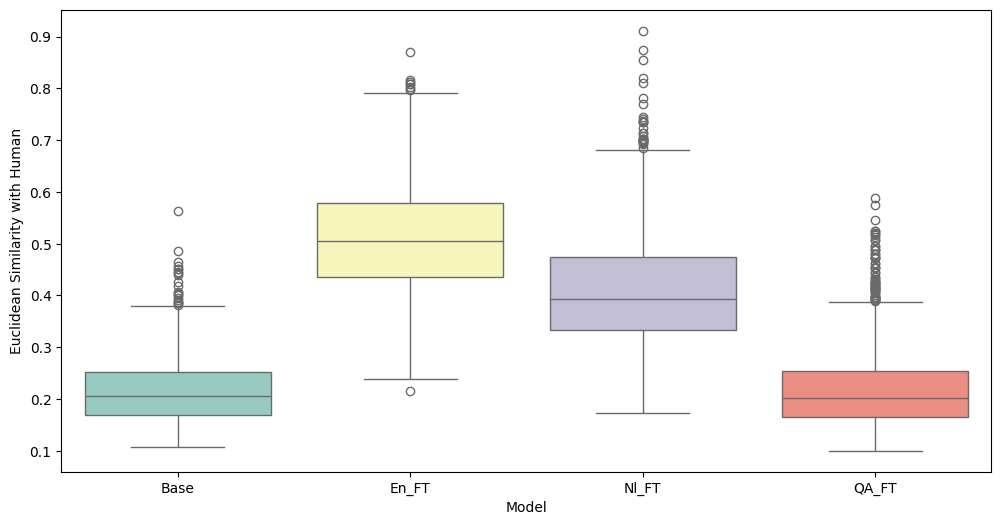

In [12]:
plt.figure(figsize=(12, 6))
plot_data = results_sim['Sensory'].melt(id_vars=['word'], value_vars=model_names, var_name='Model', value_name='CosineSimilarity')
sns.boxplot(x='Model', y='CosineSimilarity', data=plot_data, palette="Set3")
#plt.title('Distribution of Word-wise Euclidean Similarity (Sensory Dimensions)')
plt.ylabel('Euclidean Similarity with Human')
plt.show()

In [14]:
# ==========================================
# Outliers Extraction for Boxplots
# ==========================================

# 1. Helper function: Detect outliers and extract details
def extract_boxplot_outliers(sim_df, raw_df, model_names, models_dict, dim_type, dimensions):
    outlier_list = []
    
    for model_name in model_names:
        # Get all similarity scores for the model
        scores = sim_df[model_name].dropna()
        
        # --- Calculate IQR ---
        Q1 = scores.quantile(0.25)
        Q3 = scores.quantile(0.75)
        IQR = Q3 - Q1
        
       
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR 
        
        # Find outlier rows
        outliers = sim_df[(sim_df[model_name] < lower_bound) | (sim_df[model_name] > upper_bound)]
        
        if outliers.empty:
            continue
            
        print(f"[{dim_type}] Model {model_name}: Found {len(outliers)} outliers (IQR Lower: {lower_bound:.4f})")
        
        # --- Extract detailed ratings ---
        model_suffix = models_dict[model_name]
        human_suffix = models_dict['Human'] 
        
        for _, row in outliers.iterrows():
            word = row['word']
            sim_score = row[model_name]
            
            # Find raw data row
            raw_row = raw_df[raw_df['word'] == word].iloc[0]
            
            # Build record dictionary
            record = {
                'Dim_Type': dim_type,
                'Model': model_name,
                'Word': word,
                'Similarity_Score': sim_score,
                'Is_Low_Outlier': sim_score < lower_bound # Mark if low outlier
            }
            
            # Add Human rating (e.g., foot.mean)
            for d in dimensions:
                h_col = f"{d.lower()}{human_suffix}" if human_suffix.startswith('.') else f"{d.lower()}.{human_suffix}"
                if human_suffix == '': h_col = d.lower()
                if h_col in raw_df.columns:
                    record[f'Human_{d}'] = raw_row[h_col]
            
            # Add Model rating (e.g., foot_base)
            for d in dimensions:
                # Handle underscore
                m_col = f"{d.lower()}{model_suffix}" if model_suffix.startswith('_') else f"{d.lower()}_{model_suffix}"
                
                if m_col in raw_df.columns:
                    record[f'Model_{d}'] = raw_row[m_col]
            
            outlier_list.append(record)
            
    return outlier_list

# 2. Execute extraction (For Sensory, Motor, or All)
all_outliers_data = []

# Iterate all types
for target_type in ['All', 'Sensory', 'Motor']:
    if target_type in results_sim:
        print(f"\nAnalyzing outliers for {target_type} dimensions...")
        current_dims = analysis_types[target_type]
        
        outliers = extract_boxplot_outliers(
            results_sim[target_type], 
            df, # Raw large table
            model_names, 
            models, 
            target_type, 
            current_dims
        )
        all_outliers_data.extend(outliers)

# 3. Aggregate and save
df_outliers_final = pd.DataFrame(all_outliers_data)


Analyzing outliers for All dimensions...
[All] Model Base: Found 18 outliers (IQR Lower: 0.0204)
[All] Model En_FT: Found 19 outliers (IQR Lower: 0.1999)
[All] Model Nl_FT: Found 21 outliers (IQR Lower: 0.1148)
[All] Model QA_FT: Found 27 outliers (IQR Lower: 0.0379)

Analyzing outliers for Sensory dimensions...
[Sensory] Model Base: Found 21 outliers (IQR Lower: 0.0407)
[Sensory] Model En_FT: Found 9 outliers (IQR Lower: 0.2197)
[Sensory] Model Nl_FT: Found 29 outliers (IQR Lower: 0.1234)
[Sensory] Model QA_FT: Found 62 outliers (IQR Lower: 0.0315)

Analyzing outliers for Motor dimensions...
[Motor] Model Base: Found 43 outliers (IQR Lower: 0.0093)
[Motor] Model Nl_FT: Found 35 outliers (IQR Lower: 0.1164)
[Motor] Model QA_FT: Found 27 outliers (IQR Lower: 0.0296)


#### Radar Chart

In [15]:
# ==========================================
# Radar Chart for target words
# ==========================================

def plot_word_radar_chart_small_multiples(df, word, dimensions, human_suffix='.mean', models_to_plot=None, all_model_names=None, figsize_per_subplot=(4, 4)):
    """
    Plot small multiple radar charts, comparing Human ratings vs each model individually.
    Colors match the boxplot color scheme (Set3 palette).

    Parameters:
    ----------
    df : pd.DataFrame
        DataFrame containing all data.
    word : str
        Target word for visualization.
    dimensions : list
        List of dimension names.
    human_suffix : str
        Suffix for human data columns.
    models_to_plot : dict
        Dict of models to plot {Legend_Label: suffix}.
    all_model_names : list
        List of all models (used to determine color order to match boxplots).
        e.g., ['Base', 'En_FT', 'Nl_FT', 'QA_FT']
        If provided, colors are assigned based on model index in this list.
    figsize_per_subplot : tuple
        Base size for each subplot, used to calculate total figure size.
    """

    # 1. Default model configuration
    if models_to_plot is None:
        models_to_plot = {
            'Base': '_base',
            'En_FT': '_en_ft'
        }

    # 2. Get Set2 palette (consistent with boxplot)
    palette_colors = sns.color_palette("Set2", 12).as_hex()

    if all_model_names is None:
        # If no total list provided, use the current plot list
        all_model_names = list(models_to_plot.keys())

    # 3. Check if word exists
    if word not in df['word'].values:
        print(f"Error: Word '{word}' not found in the dataset.")
        return

    row = df[df['word'] == word].iloc[0]
    dims_lower = [d.lower() for d in dimensions]

    # --- Extract Human Data (Baseline) ---
    try:
        human_cols = [f"{d}{human_suffix}" for d in dims_lower]
        human_values = row[human_cols].values.astype(float).tolist()
    except KeyError as e:
        print(f"Error: Human rating columns not found. {e}")
        return

    # --- Extract Models Data ---
    model_data = {}
    for label, suffix in models_to_plot.items():
        try:
            cols = [f"{d}{suffix}" for d in dims_lower]
            vals = row[cols].values.astype(float).tolist()
            model_data[label] = vals
        except KeyError as e:
            print(f"Warning: Model '{label}' data columns not found, skipping.")

   
    if not model_data:
        print("Error: No valid model data to plot.")
        return

    # 4. Prepare radar angles and data
    N = len(dimensions)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  

    human_values_closed = human_values + human_values[:1]
    for label in model_data:
        model_data[label] = model_data[label] + model_data[label][:1]

    # 5. Calculate subplot grid layout
    num_models = len(model_data)
    
    n_cols = min(4, num_models)  
    n_rows = (num_models + n_cols - 1) // n_cols  

   
    fig_width = figsize_per_subplot[0] * n_cols
    fig_height = figsize_per_subplot[1] * n_rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                             subplot_kw={'projection': 'polar'},
                             squeeze=False)  

  
    axes_flat = axes.flatten()

    # 6. Plot in each subplot
    markers = ['s', '^', 'D', 'v', 'o', 'x', '*', 'p']

    for idx, (label, vals) in enumerate(model_data.items()):
        ax = axes_flat[idx]

        # Plot Human rating (Baseline in every subplot)
        ax.plot(angles, human_values_closed, linewidth=1.5, linestyle='--', color='gray', marker='o', markersize=3)
        ax.fill(angles, human_values_closed, 'gray', alpha=0.05)

        # Determine model color
        if label in all_model_names:
            color_idx = all_model_names.index(label)
        else:
            color_idx = idx
        color = palette_colors[color_idx % len(palette_colors)]
        marker = markers[idx % len(markers)]

        # Plot Model rating
        ax.plot(angles, vals, linewidth=2, color=color, marker=marker, markersize=4)
        ax.fill(angles, vals, color=color, alpha=0.2)

        # Set subplot title
        ax.set_title(label, size=13, fontweight='bold', pad=15)

        # Set dimension labels
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(dimensions, size=9 if n_cols <= 2 else 8)

        # Set radial ticks
        ax.set_rlabel_position(0)
        plt.setp(ax.get_yticklabels(), fontsize=8)
        ax.set_ylim(0, 5.5)
        ax.set_yticks([1, 2, 3, 4, 5])
        ax.set_yticklabels(["1", "2", "3", "4", "5"], color="grey", size=8)

        ax.grid(True, alpha=0.3)

    # 7. Hide unused subplots
    for idx in range(len(model_data), len(axes_flat)):
        axes_flat[idx].set_visible(False)

    # 8. Set Main Title and adjust layout
    fig.suptitle(f"Radar Charts for '{word}' - Model Comparison", size=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle
    plt.show()

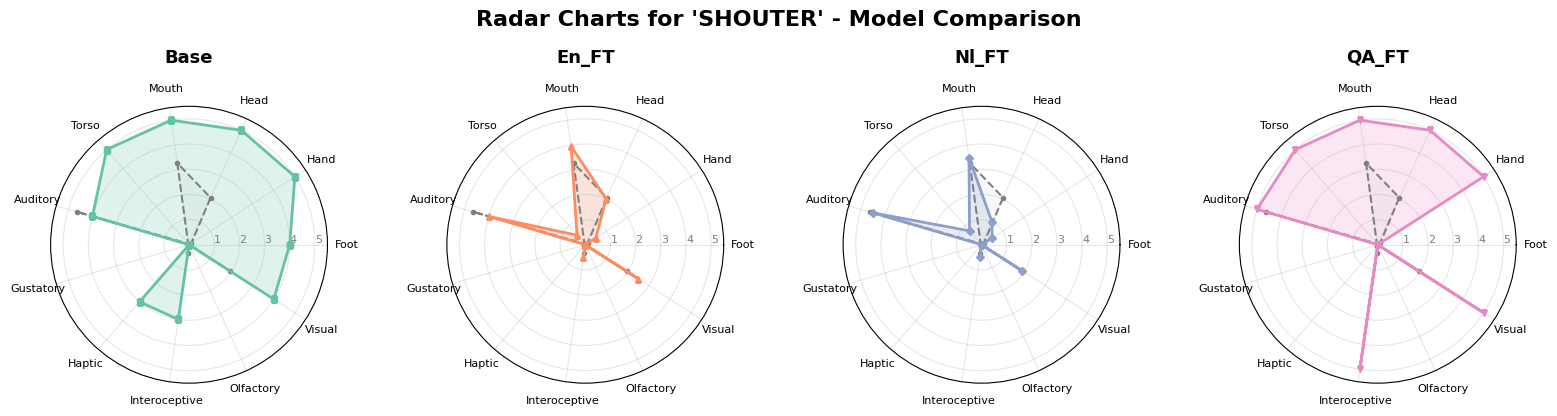

In [ ]:

models_config = {
    'Base': '_base',
    'En_FT': '_en_ft',
    'Nl_FT': '_nl_ft',
    'QA_FT': '_qa_ft'
}

# Call new function
plot_word_radar_chart_small_multiples(
    df,  # DataFrame
    'SHOUTER',  # Target Word
    all_dims,  # Dimension List
    human_suffix='.mean',
    models_to_plot=models_config,
    all_model_names=['Base', 'En_FT', 'Nl_FT', 'QA_FT'], 
    figsize_per_subplot=(4, 4)  # Subplot size
)

#### Heatmap

In [46]:
# ============================================
# Heatmap of Spearman Correlation Coefficients
# ============================================

def analyze_similarity_correlations(results_dict, model_list):
    """
    Calculate Spearman correlation coefficients between "Similarity with Human" distributions of different models.
    Mark significance levels in the heatmap:
    *   p < 0.05
    **  p < 0.01
    *** p < 0.001
    """
    
    for dim_type, df_sim in results_dict.items():
        print(f"\n{'='*50}")
        print(f">>> Spearman Correlation Analysis: {dim_type} Dimensions")
        print(f"{'='*50}")
        
        # 1. Extract subset containing only model scores
        df_scores = df_sim[model_list].dropna()
        
        # 2. Calculate Spearman correlation and P-values
        rho, p_values = spearmanr(df_scores)
        
        # Convert to DataFrame for easier handling (keep labels)
        rho_df = pd.DataFrame(rho, index=df_scores.columns, columns=df_scores.columns)
        p_df = pd.DataFrame(p_values, index=df_scores.columns, columns=df_scores.columns)
        
        print("Correlation Matrix (Rho):")
        print(rho_df)
        
        # 3. Create annotation matrix with asterisks (for annot parameter)
        annot_matrix = pd.DataFrame(index=df_scores.columns, columns=df_scores.columns)
        
        for i in range(len(rho_df)):
            for j in range(len(rho_df)):
                r = rho_df.iloc[i, j]
                p = p_df.iloc[i, j]
                
                text = f"{r:.3f}"
                
                # Add significance markers (exclude diagonal, diagonal is always 1)
                if i != j: 
                    if p < 0.001:
                        text += "***"
                    elif p < 0.01:
                        text += "**"
                    elif p < 0.05:
                        text += "*"
                
                annot_matrix.iloc[i, j] = text
        

        # np.triu(np.ones_like(...)) generates upper triangle as True, seaborn will hide True parts
        mask = np.triu(np.ones_like(rho_df, dtype=bool))
        
        # 4. Plot Heatmap
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            rho_df, 
            annot=annot_matrix.values, 
            mask=mask, 
            fmt="",            
            cmap='RdBu_r', 
            vmin=-1.0, vmax=1.0, 
            square=True,
            cbar_kws={'label': 'Spearman Correlation (rank)'}
        )
        plt.title(f"Correlation between Model Performances\n(Based on similarity to Human in {dim_type} dims)", fontsize=13)
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()


>>> Spearman Correlation Analysis: All Dimensions
Correlation Matrix (Rho):
           Base     En_FT     Nl_FT     QA_FT
Base   1.000000 -0.047008 -0.151811  0.655765
En_FT -0.047008  1.000000  0.367581  0.074692
Nl_FT -0.151811  0.367581  1.000000 -0.024777
QA_FT  0.655765  0.074692 -0.024777  1.000000


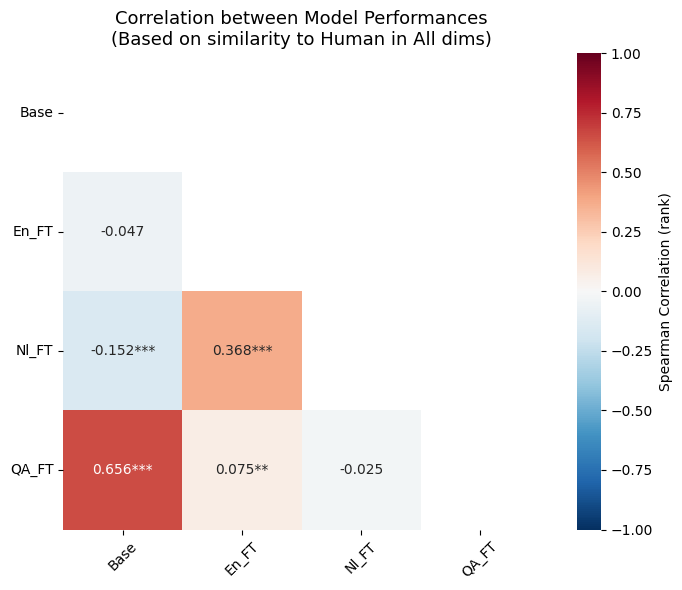


>>> Spearman Correlation Analysis: Motor Dimensions
Correlation Matrix (Rho):
           Base     En_FT     Nl_FT     QA_FT
Base   1.000000 -0.104600 -0.239678  0.563104
En_FT -0.104600  1.000000  0.300395  0.105192
Nl_FT -0.239678  0.300395  1.000000  0.031246
QA_FT  0.563104  0.105192  0.031246  1.000000


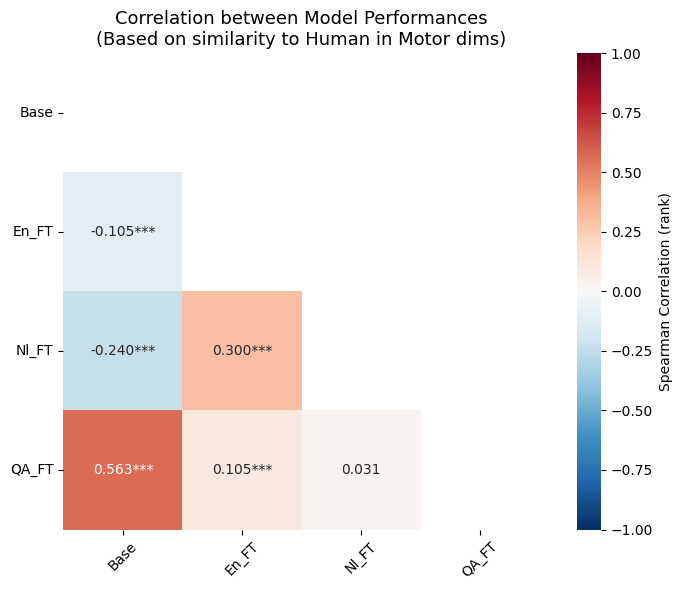


>>> Spearman Correlation Analysis: Sensory Dimensions
Correlation Matrix (Rho):
           Base     En_FT     Nl_FT     QA_FT
Base   1.000000 -0.048922 -0.240979  0.649373
En_FT -0.048922  1.000000  0.484023  0.032773
Nl_FT -0.240979  0.484023  1.000000 -0.193322
QA_FT  0.649373  0.032773 -0.193322  1.000000


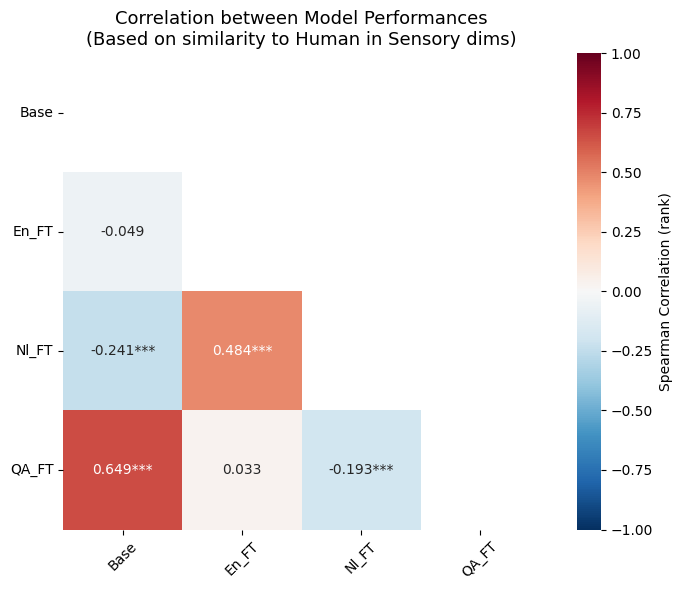

In [18]:
analyze_similarity_correlations(results_sim, model_names)

#### Scatter Plot

In [48]:
# ============================================
# Scatter Plot Visualization
# ============================================

def plot_model_comparison_scatter(df_sim, model_x, model_y, title_type):
    plt.figure(figsize=(8, 8))
    
    # Get data and drop NaN
    temp_df = df_sim[[model_x, model_y]].dropna()
    x_data = temp_df[model_x]
    y_data = temp_df[model_y]
    
    # Plot Scatter
    plt.scatter(x_data, y_data, alpha=0.5, s=10, c='#3498db')
    
    # Plot Diagonal y=x
    min_val = min(x_data.min(), y_data.min())
    max_val = max(x_data.max(), y_data.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Equal Performance', linewidth=1.5)
    
    # Set labels and title
    plt.xlabel(f'Euclidean Similarity ({model_x} vs Human)', fontsize=12)
    plt.ylabel(f'Euclidean Similarity ({model_y} vs Human)', fontsize=12)
    plt.title(f'Word-wise Performance Comparison: {model_x} vs {model_y} ({title_type} Dims)', fontsize=14)
    
    # --- Calculate and Show Spearman Correlation ---
    rho, p_val = spearmanr(x_data, y_data)
    
    p_text = "p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
    stats_text = f"Spearman r = {rho:.3f}\n{p_text}"
    
    # Add stats box to top left (use relative coordinates 0.05, 0.95 to avoid blocking data)
    count_x_better = sum(x_data > y_data)
    count_y_better = sum(y_data > x_data)
    plt.text(0.05, 0.95, stats_text + f'\n{model_x} better: {count_x_better}\n{model_y} better: {count_y_better}', transform=plt.gca().transAxes,
             ha='left', va='top', fontsize=10,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='#bdc3c7', boxstyle='round,pad=0.5'))

    
    plt.legend(loc='lower right', bbox_to_anchor=(1, 0.15)) # Adjust legend position
    plt.grid(True, alpha=0.3)
    plt.show()

正在生成 All 维度的所有模型两两对比散点图 (6 张)...


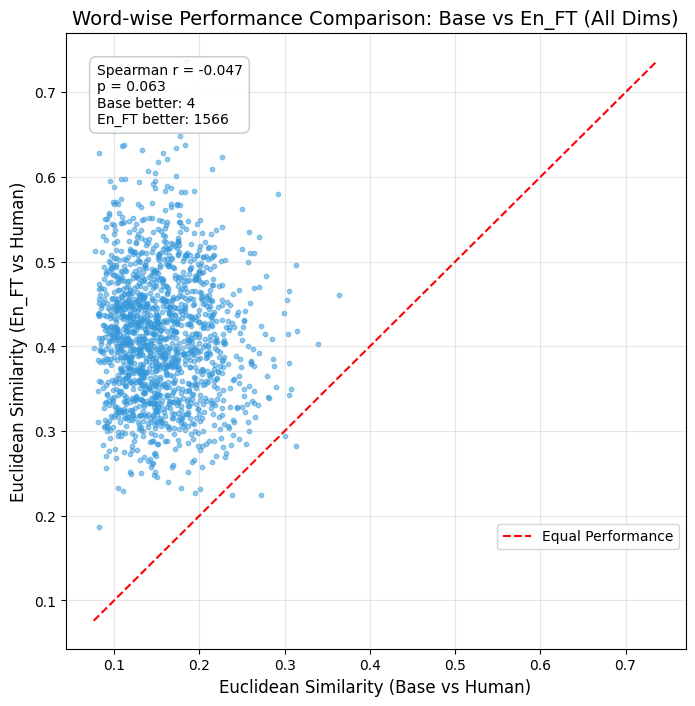

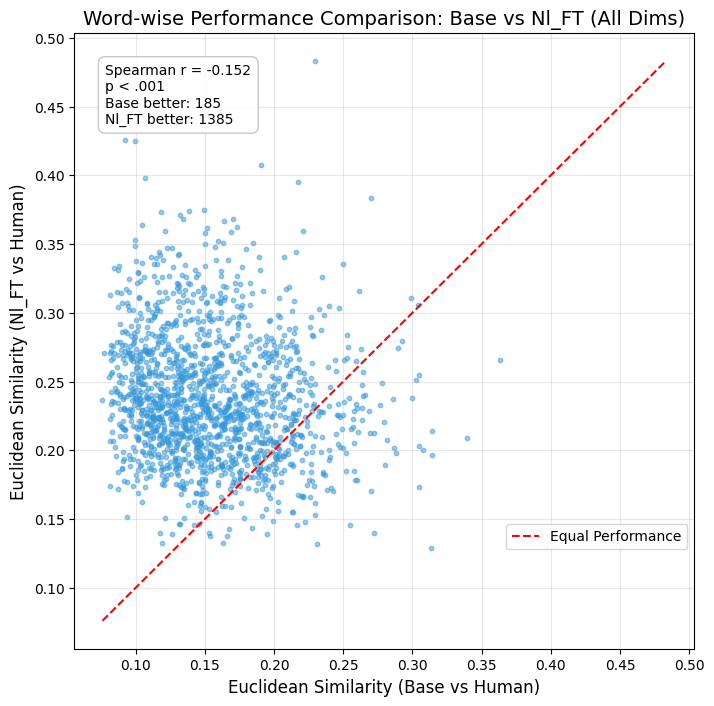

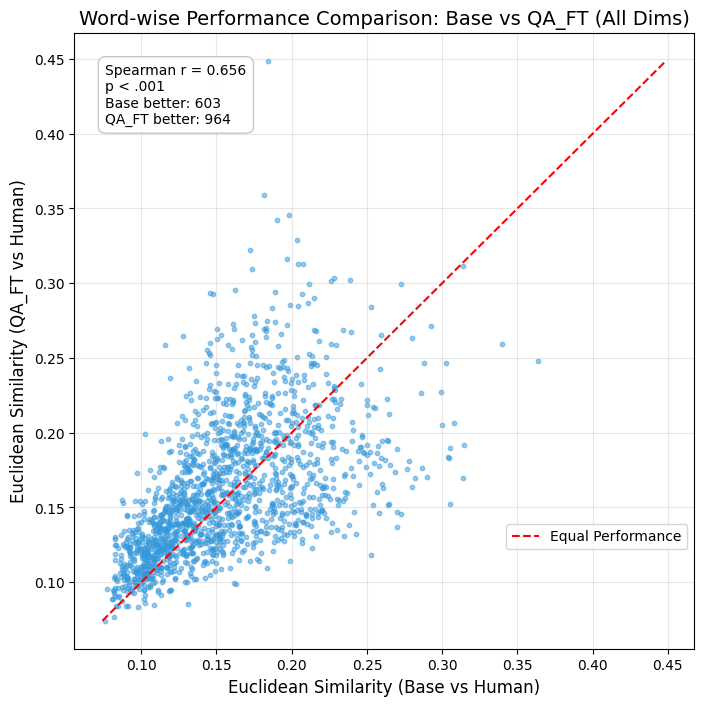

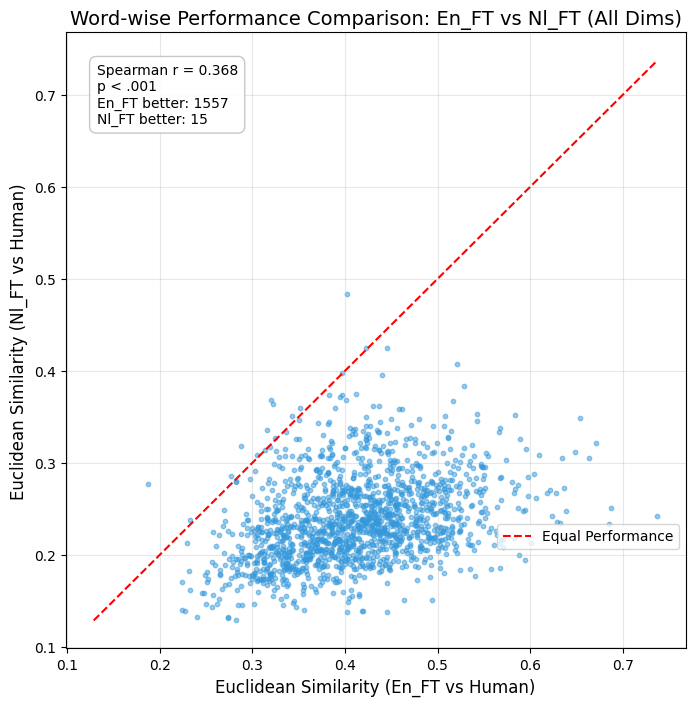

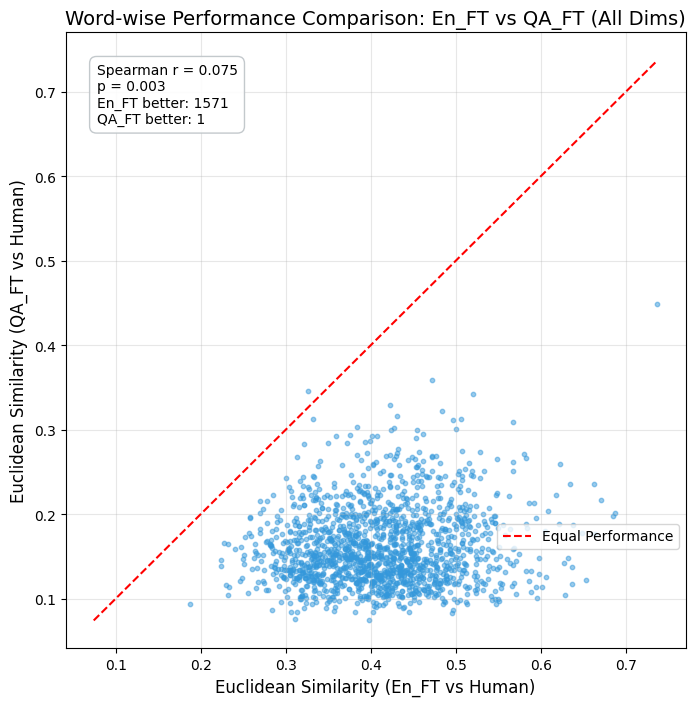

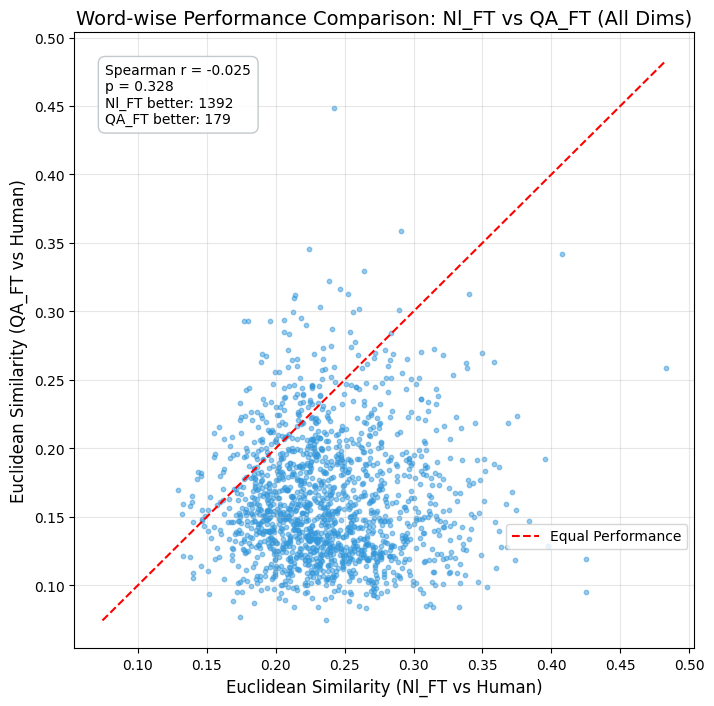

In [ ]:
# --- Batch Plot All Pairwise Scatter Plots ---

# Select dimension type to analyze ('All', 'Motor', 'Sensory')
target_type = 'All'  

# Generate all pairwise combinations
pairs = list(itertools.combinations(model_names, 2))

print(f"Generating scatter plots for all pairwise model comparisons in {target_type} dimensions ({len(pairs)} plots)...")

for m1, m2 in pairs:
    plot_model_comparison_scatter(results_sim[target_type], m1, m2, target_type)

## Dutch Dataset

In [22]:
# 1. Define dimensions

nl_dims = ["Horen", "Proeven", "Voelen", "Sensaties", "Ruiken", "Zien"]


# 2. Define model list
models_nl = {
    'Human': '',  
    'Base': '_base',
    'En_FT': '_en_ft',
    'Nl_FT': '_nl_ft'
}
model_names_nl = ['Base', 'En_FT', 'Nl_FT']

# 3. Load data
file_path = "Nl_all_models_results.xlsx"  

df_nl = pd.read_excel(file_path)
df_nl.columns = df_nl.columns.str.lower()
print("Data loaded successfully, rows:", len(df_nl))

Data loaded successfully, rows: 1572


### calculate similarity

In [30]:
# Calculate similarity list
results_sim_nl = {}

analysis_types_nl = {
    'Nl': nl_dims
}

print("\nCalculating Euclidean similarity (1/(1+d))...")
for type_name, dims in analysis_types_nl.items():
    print(f"--- Processing {type_name} Dimensions ---")
    results_sim_nl[type_name] = pd.DataFrame({'word': df_nl['word']}) 
  

    for model_name in model_names_nl:
        model_suffix = models_nl[model_name]
        human_suffix = models_nl['Human']

        # Calculate Similarity for each row (word)
        sim_scores = df_nl.apply(lambda row: calculate_euclidean_based_sim(row, model_suffix, human_suffix, dims), axis=1)
        results_sim_nl[type_name][model_name] = sim_scores
        
        print(f"{model_name} vs Human (Mean Sim): {sim_scores.mean():.4f}")

# Save to Excel
output_file = "nl_word_wise_similarity_results.xlsx"
results_sim_nl.to_excel(output_file, sheet_name='Sensory', index=False)
print(f"\nResults saved to '{output_file}' with shape: {results_sim_nl.shape}")


Calculating Euclidean similarity (1/(1+d))...
--- Processing Nl Dimensions ---
Base vs Human (Mean Sim): 0.1598
Base vs Human (Mean Sim): 0.1598
En_FT vs Human (Mean Sim): 0.4581
Nl_FT vs Human (Mean Sim): 0.4984
En_FT vs Human (Mean Sim): 0.4581
Nl_FT vs Human (Mean Sim): 0.4984


In [31]:
print_distribution_statistics(results_sim_nl, model_names_nl)


STATISTICAL DISTRIBUTION SUMMARY (Descriptive Statistics)

>>> Dimension Type: Nl
------------------------------------------------------------
        mean    std    min    25%    50%    75%    max
Base  0.1598 0.0364 0.0896 0.1345 0.1531 0.1794 0.3904
En_FT 0.4581 0.1055 0.1368 0.3817 0.4476 0.5210 0.8927
Nl_FT 0.4984 0.1157 0.1747 0.4142 0.4890 0.5744 0.9208
------------------------------------------------------------
Interquartile Range (IQR):
Base    0.0449
En_FT   0.1393
Nl_FT   0.1602
dtype: float64


In [41]:
# Pairwise T-test
perform_statistical_tests(results_sim_nl["Nl"], 'Nl', model_names_nl)


=== Statistical Test Results (Nl) ===
Comparison           | T-stat     | P-value    | Sig
-------------------------------------------------------
Base vs En_FT      | -111.7168    | 0.00e+00   | ***
Base vs Nl_FT      | -106.3672    | 0.00e+00   | ***
En_FT vs Nl_FT      | -11.5054    | 1.81e-29   | ***


### Visualization

/var/folders/tb/rtz1nxvn4k5_jn2c158qm_wm0000gn/T/ipykernel_37374/2532625833.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='EuclideanSimilarity', data=plot_data, palette="Set3")


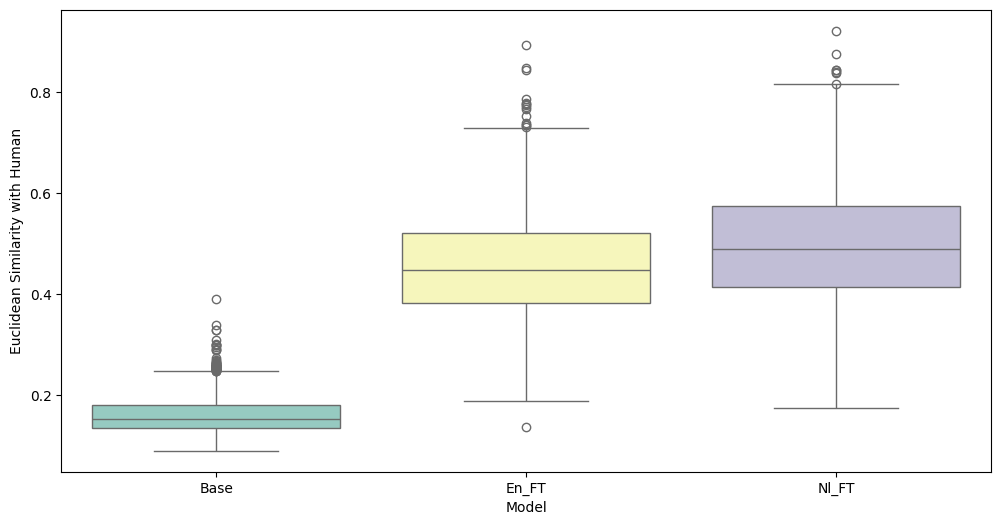

In [44]:
# Visualize distribution with Boxplots
plt.figure(figsize=(12, 6))
plot_data = results_sim_nl['Nl'].melt(id_vars=['word'], value_vars=model_names_nl, var_name='Model', value_name='EuclideanSimilarity')
sns.boxplot(x='Model', y='EuclideanSimilarity', data=plot_data, palette="Set3")
#plt.title('Dutch Dataset: Distribution of Word-wise Euclidean Similarity')
plt.ylabel('Euclidean Similarity with Human')
plt.show()


>>> Spearman Correlation Analysis: Nl Dimensions
Correlation Matrix (Rho):
         Base  En_FT   Nl_FT
Base   1.0000 0.1650 -0.1445
En_FT  0.1650 1.0000  0.2110
Nl_FT -0.1445 0.2110  1.0000


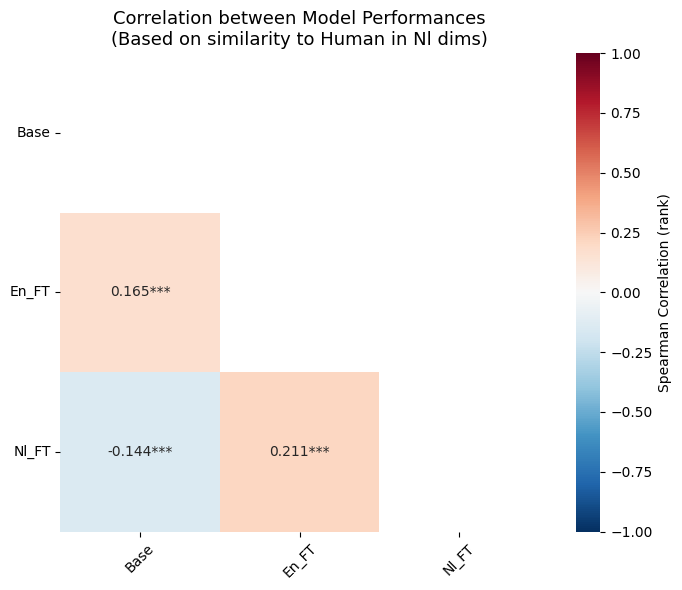

In [47]:
if 'results_sim_nl' in locals() and 'model_names_nl' in locals():
    analyze_similarity_correlations(results_sim_nl, model_names_nl)
else:
    print("Error: Variables 'results_sim' or 'model_names' not defined. Please run previous calculation cells.")

Generating scatter plots for all pairwise model comparisons in Dutch set (3 plots)...


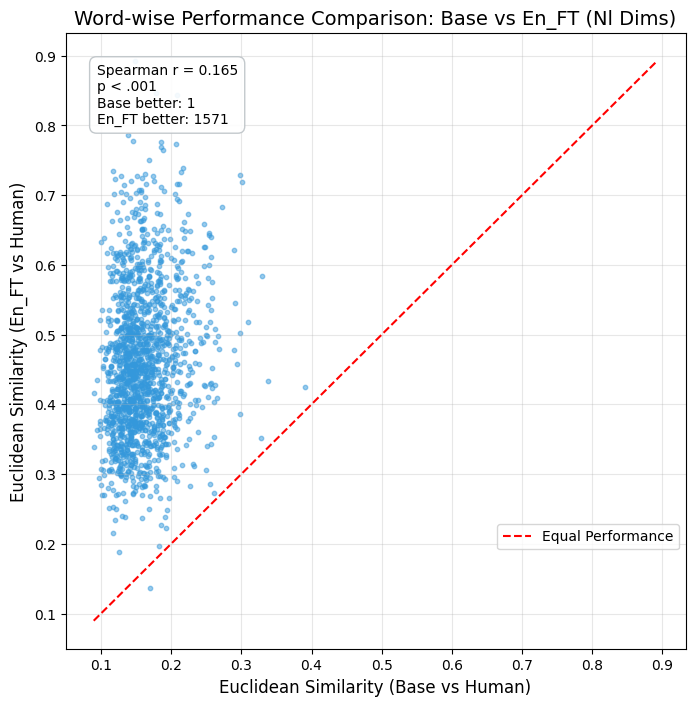

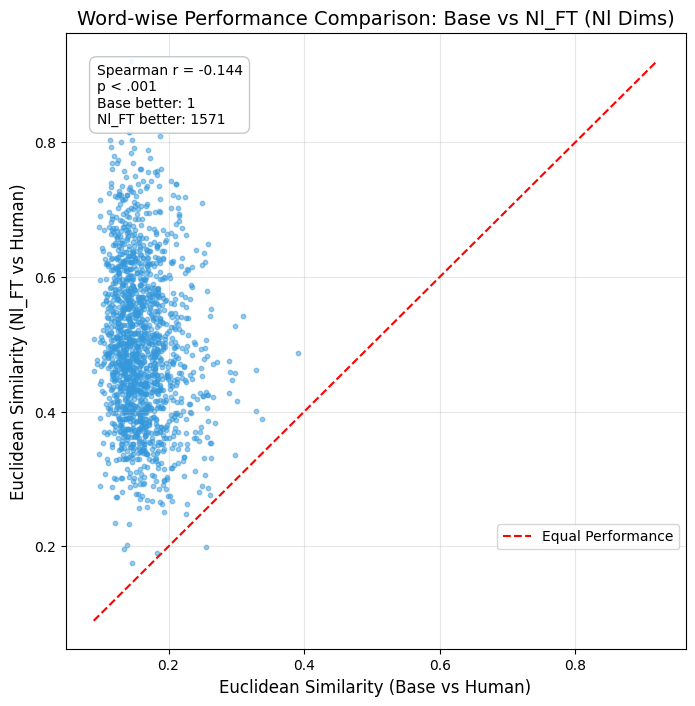

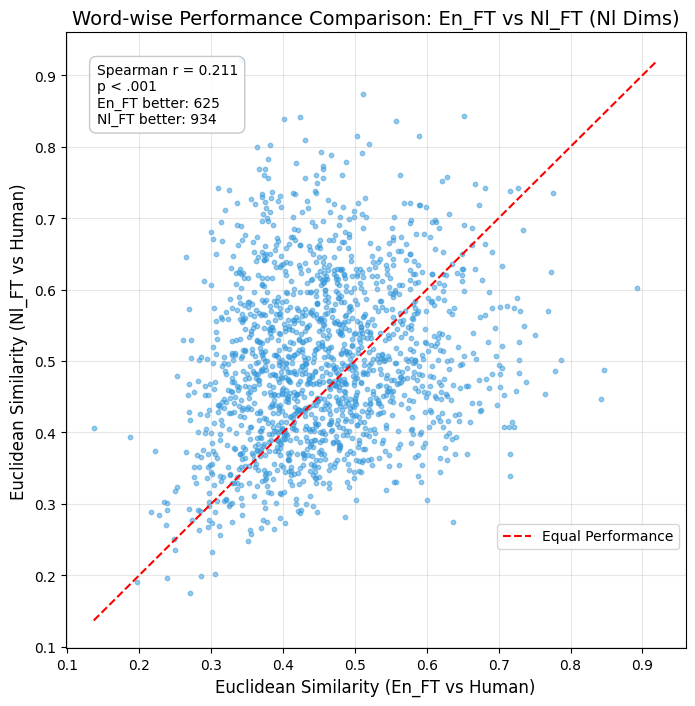

In [52]:
# --- Batch Plot All Pairwise Scatter Plots ---

# Generate all pairwise combinations
pairs = list(itertools.combinations(model_names_nl, 2))

print(f"Generating scatter plots for all pairwise model comparisons in Dutch set ({len(pairs)} plots)...")

for m1, m2 in pairs:
    plot_model_comparison_scatter(results_sim_nl['Nl'], m1, m2, "Nl")